# 03 · Modelo: Árbol de decisión

**Proyecto Final — Machine Learning y Deep Learning**

Este notebook se centra en **un solo modelo**: preguntas sí/no encadenadas; **no lineal** e interpretable. Sigue la misma estructura que el resto de notebooks de modelo, para poder compararlos con facilidad.

> 📖 Términos técnicos explicados en `docs/glosario.md`. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb); la comparación de todos los modelos, en [`07_comparativa_modelos.ipynb`](07_comparativa_modelos.ipynb).

## 1. Cómo funciona

Un **árbol de decisión** hace **preguntas sí/no** encadenadas sobre las variables (p. ej. *¿`lead_time` > 100?*), dividiendo los datos en ramas hasta llegar a **hojas** que predicen una clase. En cada división elige la pregunta que **mejor separa** las clases (según una medida de impureza como *gini* o *entropy*).

Es **no lineal** y muy interpretable (se puede dibujar el árbol y leer las reglas), pero un árbol que crece sin límite tiende a **sobreajustar** (memorizar el entrenamiento). Por eso se controla su tamaño.

## 2. Los datos

Usamos el **mismo preprocesado compartido** por todos los modelos (`src/preprocessing.py`): imputación de huecos, estandarización de las numéricas y *one-hot* de las categóricas. El análisis de los datos está en [`01_eda.ipynb`](01_eda.ipynb). Cargamos y dividimos en train/test (estratificado, semilla fija) con `load_and_prepare()`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
# Importamos solo el CONTRATO del pipeline (mismos datos y preprocesado que producción):
from ml_hotel_cancellations import config
from ml_hotel_cancellations.ml.data_loader import load_and_prepare
from ml_hotel_cancellations.ml.preprocessing import build_preprocessor

X_train, X_test, y_train, y_test = load_and_prepare()
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

def evaluar(pipe, X_test, y_test, etiqueta='Modelo'):
    """Métricas de test del pipeline (parte de la exploración, por eso vive aquí)."""
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    m = dict(accuracy=accuracy_score(y_test, pred), precision=precision_score(y_test, pred),
             recall=recall_score(y_test, pred), f1=f1_score(y_test, pred),
             roc_auc=roc_auc_score(y_test, proba))
    print(f"{etiqueta:12s} | " + ' | '.join(f'{k}={v:.4f}' for k, v in m.items()))
    return m['roc_auc']

Entrenamiento: (95368, 28) | Prueba: (23842, 28)


## 3. Los hiperparámetros: ¿qué controla cada uno?

Los **hiperparámetros** son los ajustes que fijamos *antes* de entrenar (no se aprenden de los datos). Estos son los principales de este modelo:

| Hiperparámetro | Qué controla |
|---|---|
| `max_depth` | Profundidad máxima del árbol. Más profundo → más complejo y mayor riesgo de sobreajuste. |
| `min_samples_leaf` | Mínimo de muestras en una hoja. Más alto → hojas más "pobladas" → árbol más simple y robusto. |
| `criterion` | Medida de impureza para elegir las divisiones (`gini` o `entropy`). |
| `min_samples_split` | Mínimo de muestras para poder dividir un nodo. |

## 4. Entrenamiento y evaluación (parámetros base)

Entrenamos el modelo con los hiperparámetros base y lo evaluamos sobre el conjunto de prueba (datos que no vio al entrenar).

In [2]:
# Pipeline = preprocesado + modelo (con los hiperparámetros base del proyecto)
from sklearn.tree import DecisionTreeClassifier
modelo = Pipeline([('preprocessor', build_preprocessor()), ('model', DecisionTreeClassifier(**config.DECISION_TREE_PARAMS))])
modelo.fit(X_train, y_train)
auc_base = evaluar(modelo, X_test, y_test, 'Base')

Base         | accuracy=0.8540 | precision=0.8257 | recall=0.7683 | f1=0.7960 | roc_auc=0.9337


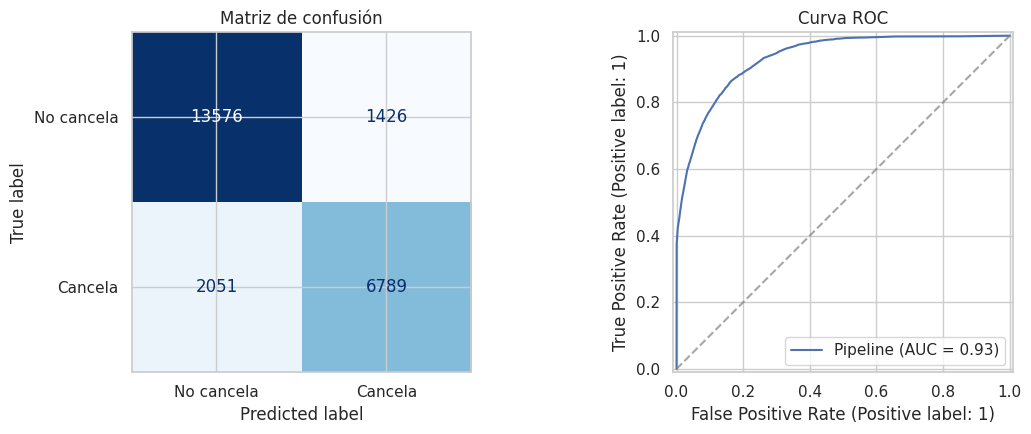

In [3]:
# Matriz de confusión y curva ROC de este modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, ax=ax1,
    display_labels=['No cancela', 'Cancela'], cmap='Blues', colorbar=False)
ax1.set_title('Matriz de confusión')
RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax2)
ax2.plot([0, 1], [0, 1], '--', color='gray', alpha=0.7); ax2.set_title('Curva ROC')
plt.tight_layout(); plt.show()

## 5. Visualización del modelo

Visualizamos el **árbol** entrenado (primeros niveles): las preguntas sí/no que hace y cómo va separando las clases..

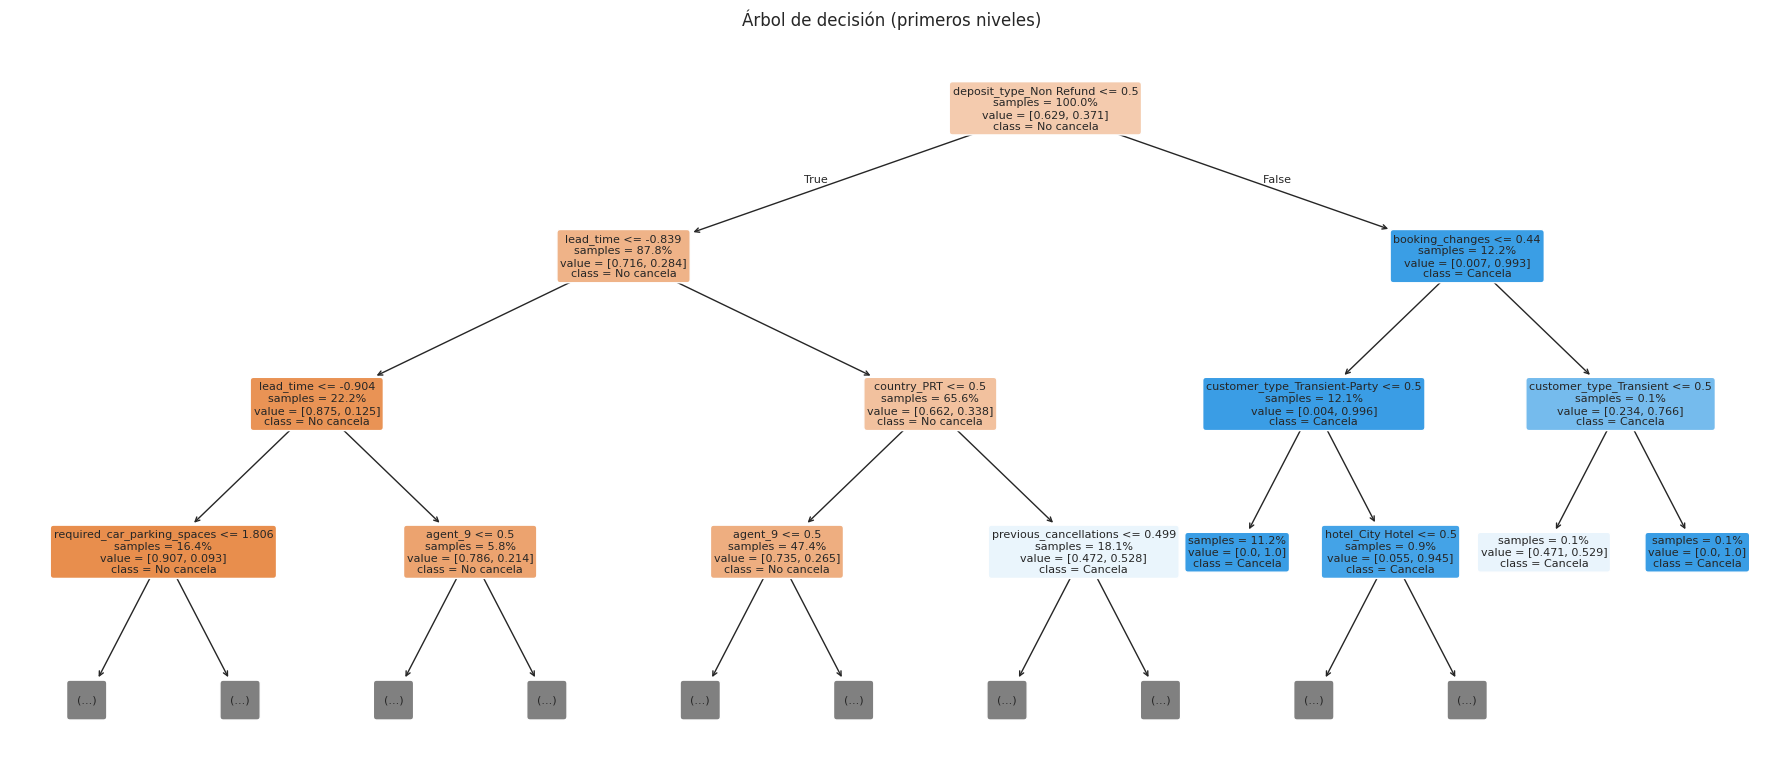

In [4]:
# El árbol entrenado (primeros niveles): las preguntas sí/no que hace.
from sklearn.tree import plot_tree
nombres = modelo.named_steps['preprocessor'].get_feature_names_out()
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(modelo.named_steps['model'], max_depth=3, feature_names=nombres,
          class_names=['No cancela', 'Cancela'], filled=True, rounded=True,
          proportion=True, impurity=False, fontsize=8, ax=ax)
ax.set_title('Árbol de decisión (primeros niveles)')
plt.tight_layout(); plt.show()

## 6. Optimización de hiperparámetros

Buscamos la mejor combinación con **GridSearchCV (búsqueda exhaustiva)**, optimizando **ROC-AUC** por validación cruzada. (Es el mismo procedimiento, por modelo, que automatiza `src/tuning.py` para todo el proyecto.)

In [5]:
from sklearn.model_selection import GridSearchCV

base_pipe = Pipeline([('preprocessor', build_preprocessor()), ('model', DecisionTreeClassifier(random_state=config.RANDOM_STATE))])
busqueda = GridSearchCV(base_pipe, config.DECISION_TREE_GRID, scoring='roc_auc', cv=config.TUNING_CV_FOLDS, n_jobs=-1)
busqueda.fit(X_train, y_train)
print('Mejores hiperparámetros:', busqueda.best_params_)
print(f'ROC-AUC (validación cruzada, {config.TUNING_CV_FOLDS} folds): {busqueda.best_score_:.4f}')

Mejores hiperparámetros: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 50}
ROC-AUC (validación cruzada, 3 folds): 0.9341


## 7. Resultado final y cuándo usar este modelo

Comparamos el rendimiento en test **antes y después** de optimizar:

In [6]:
auc_tuned = evaluar(busqueda.best_estimator_, X_test, y_test, 'Optimizado')
print(f'\nROC-AUC en test:  base {auc_base:.4f}  ->  optimizado {auc_tuned:.4f}')

Optimizado   | accuracy=0.8585 | precision=0.8307 | recall=0.7768 | f1=0.8028 | roc_auc=0.9369

ROC-AUC en test:  base 0.9337  ->  optimizado 0.9369


**Cuándo conviene:** cuando quieres **reglas claras e interpretables**, o como bloque de construcción de modelos de conjunto (Random Forest, XGBoost). Por sí solo suele rendir menos que esos conjuntos.